<a href="https://colab.research.google.com/github/ycai4891-tech/market-analysis/blob/main/bitcoin_trend_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trend-Following on Bitcoin

**A moving-average crossover backtested against buy and hold, 2014 to 2026**
Yanyan Cai &middot; MSc Business Analytics and Financial Technology, University of Dundee

A companion to the Bloomberg technical-analysis work on XBTUSD, which read RSI,
MACD and Bollinger Bands across the LUNA and FTX cycle. That study described what
the indicators did. This one asks whether acting on one of them would have paid:
over Bitcoin's full traded history, does a simple trend filter improve
**risk-adjusted** return, or does it only look good because of when you started?

The same notebook was first run on the FTSE 100, where the answer was no. Section 6
re-runs both assets side by side, because a rule that works on one market and not
another is a fact about the market, not about the rule.

### What this notebook actually tests

A 50/200-day moving-average crossover. Long Bitcoin when the fast average is above
the slow one, flat otherwise. This is the most-published rule in technical analysis,
which is exactly why it is worth testing properly rather than quoting.

### How it avoids flattering itself

- the signal is **lagged one day**, so a crossover seen at Monday's close is traded
  at Tuesday's
- **transaction costs** of 10bps are charged on every position change
- **63 parameter pairs** are swept, so the result is not one lucky setting
- the finding is reported whichever way it comes out


In [1]:
!pip install yfinance --quiet
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Annualisation is derived per asset in section 1, not hardcoded: an equity index
# has ~252 observations a year, Bitcoin ~365. Using 252 for both would overstate
# Bitcoin's history by 45% and distort every annualised figure.
def periods_per_year(idx):
    span_years = (idx[-1] - idx[0]).days / 365.25
    return len(idx) / span_years

# Palette: two categorical hues, validated for colour-vision deficiency separation.
BUYHOLD, STRATEGY = "#eb6834", "#2a78d6"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#dcdbd6", "#fcfcfb"
BLUE_RAMP = ["#cde2fb","#9ec5f4","#6da7ec","#3987e5","#256abf","#184f95","#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})

## 1. Data

Daily BTC-USD closes from Yahoo Finance, starting 17 September 2014, the first date
with a continuous daily series. Bitcoin pays no dividend and has no total-return
version, so the price series *is* the return series, and the buy-and-hold leg needs
no adjustment. That removes the largest fudge factor in the FTSE 100 version of this
study, where the price index understated buy and hold by the dividend yield.

**Annualisation is derived from the data, not assumed.** Bitcoin trades every day of
the year, an equity index roughly 252. Hardcoding 252 for both, which is the usual
shortcut, would report Bitcoin's twelve years of history as seventeen and scale every
annualised figure by 20%. The cell below counts observations per year from the index
itself, so the same code is correct for either asset.

One caveat stays: the series starts after Bitcoin's first two boom-bust cycles, and
it covers a period in which the asset rose roughly 170-fold. Any long-biased rule
looks good against that backdrop. The parameter sweep in section 5 is what tests
whether the *rule* did the work.


In [2]:
TICKER = "BTC-USD"
START, END = "2014-09-17", "2026-08-31"

raw = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=True)
px = raw["Close"]
if isinstance(px, pd.DataFrame):
    px = px.iloc[:, 0]
px = px.dropna()

PPY = periods_per_year(px.index)
print(f"{TICKER}: {len(px):,} observations, {px.index[0].date()} to {px.index[-1].date()}")
print(f"observations per year: {PPY:.0f}   history: {len(px)/PPY:.1f} years")
px.head()


BTC-USD: 4,366 observations, 2014-09-17 to 2026-08-30
observations per year: 365   history: 12.0 years


,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014


## 2. Signal

`Position` is 1 when the 50-day average sits above the 200-day average, else 0.
The `.shift(1)` is the entire integrity of the backtest: it means a crossover
observed at Monday's close is traded at Tuesday's, which is the earliest a real
account could act. Bitcoin trades every day, so unlike an equity index there is no
weekend gap to hide behind.


In [3]:
FAST, SLOW, COST_BPS = 50, 200, 10.0

def build_signals(price, fast=FAST, slow=SLOW):
    s = pd.DataFrame(index=price.index)
    s["Price"] = price
    s["Fast"]  = price.rolling(fast).mean()
    s["Slow"]  = price.rolling(slow).mean()
    # shift(1): act tomorrow on what we saw today. Removing this creates lookahead bias.
    s["Position"] = (s["Fast"] > s["Slow"]).astype(int).shift(1).fillna(0)
    return s

sig = build_signals(px)
in_market = sig["Position"].mean()
print(f"time in market: {in_market:.1%}")
sig.tail(3)

time in market: 57.8%


,Price,Fast,Slow,Position
Date,,,,
2026-08-28,77830.289062,66721.753437,69263.118750,0.0
2026-08-29,78245.812500,67004.126875,69310.378008,0.0
2026-08-30,77667.570312,67281.437734,69363.756016,0.0


## 3. Backtest

In [4]:
def backtest(s, cost_bps=COST_BPS):
    r = s["Price"].pct_change().fillna(0.0)
    trades = s["Position"].diff().abs().fillna(0.0)
    out = pd.DataFrame({
        "BuyHold":  r,
        "Strategy": s["Position"] * r - trades * (cost_bps / 10_000.0),
    })
    out["BuyHold_Cum"]  = (1 + out["BuyHold"]).cumprod()
    out["Strategy_Cum"] = (1 + out["Strategy"]).cumprod()
    return out, int(trades.sum())

def max_drawdown(cum):
    return float((cum / cum.cummax() - 1).min())

def stats(r, cum, ppy):
    years = len(r) / ppy
    cagr  = float(cum.iloc[-1] ** (1 / years) - 1)
    vol   = float(r.std() * np.sqrt(ppy))
    down  = float(r[r < 0].std() * np.sqrt(ppy))
    mdd   = max_drawdown(cum)
    return {
        "Total Return":  f"{cum.iloc[-1] - 1:.1%}",
        "CAGR":          f"{cagr:.2%}",
        "Volatility":    f"{vol:.2%}",
        "Sharpe":        f"{r.mean() * ppy / vol:.2f}",
        "Sortino":       f"{r.mean() * ppy / down:.2f}",
        "Max Drawdown":  f"{mdd:.1%}",
        "Calmar":        f"{cagr / abs(mdd):.2f}",
    }

res, n_trades = backtest(sig)
summary = pd.DataFrame({
    "Buy & Hold":   stats(res["BuyHold"],  res["BuyHold_Cum"],  PPY),
    "MA Crossover": stats(res["Strategy"], res["Strategy_Cum"], PPY),
})
print(f"round trips: {n_trades // 2}   position changes: {n_trades}")
summary

round trips: 10   position changes: 20


,Buy & Hold,MA Crossover
Total Return,16882.7%,13628.7%
CAGR,53.67%,50.96%
Volatility,66.27%,53.93%
Sharpe,0.98,1.04
Sortino,1.30,1.05
Max Drawdown,-83.4%,-69.3%
Calmar,0.64,0.74


The two rows that matter are **Max Drawdown** and **Sharpe**. Total return is the
number everyone looks at and the least informative one, because it is dominated by
the start and end dates you happened to choose.

## 4. Charts

Two charts, one measure each. Growth of £1 shows what happened; the drawdown chart
shows what it felt like to hold.

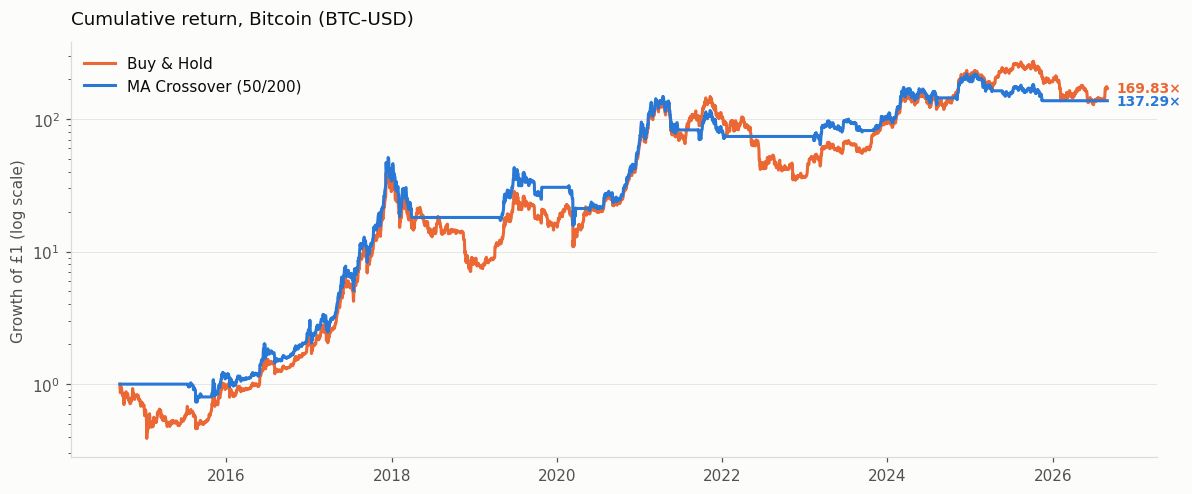

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(res.index, res["BuyHold_Cum"],  color=BUYHOLD,  lw=2, label="Buy & Hold")
ax.plot(res.index, res["Strategy_Cum"], color=STRATEGY, lw=2, label="MA Crossover (50/200)")
ax.set_yscale("log")
ax.set_ylabel("Growth of \u00a31 (log scale)")
ax.set_title("Cumulative return, Bitcoin (BTC-USD)", loc="left", fontsize=12, color=INK, pad=12)
ax.grid(axis="y", alpha=0.7)
ax.legend(frameon=False, loc="upper left")
for name, col in [("BuyHold_Cum", BUYHOLD), ("Strategy_Cum", STRATEGY)]:
    ax.annotate(f"{res[name].iloc[-1]:.2f}\u00d7",
                xy=(res.index[-1], res[name].iloc[-1]),
                xytext=(6, 0), textcoords="offset points",
                color=col, fontsize=9, va="center", fontweight="bold")
plt.tight_layout(); plt.show()

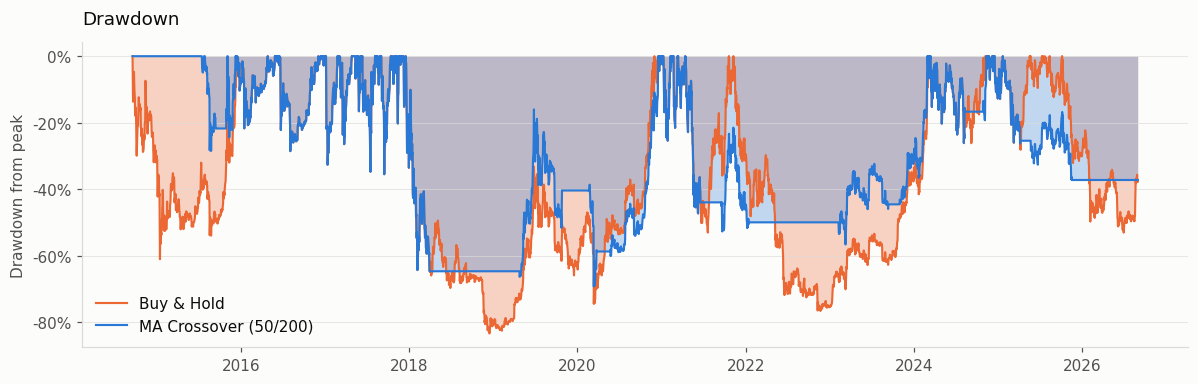

worst drawdown   buy & hold -83.4%   strategy -69.3%


In [6]:
dd_bh = res["BuyHold_Cum"]  / res["BuyHold_Cum"].cummax()  - 1
dd_st = res["Strategy_Cum"] / res["Strategy_Cum"].cummax() - 1

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.fill_between(res.index, dd_bh, 0, color=BUYHOLD,  alpha=0.28, lw=0)
ax.fill_between(res.index, dd_st, 0, color=STRATEGY, alpha=0.28, lw=0)
ax.plot(res.index, dd_bh, color=BUYHOLD,  lw=1.4, label="Buy & Hold")
ax.plot(res.index, dd_st, color=STRATEGY, lw=1.4, label="MA Crossover (50/200)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_ylabel("Drawdown from peak")
ax.set_title("Drawdown", loc="left", fontsize=12, color=INK, pad=12)
ax.grid(axis="y", alpha=0.7)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout(); plt.show()

print(f"worst drawdown   buy & hold {dd_bh.min():.1%}   strategy {dd_st.min():.1%}")

## 5. Is this curve fitting?

The test that separates a real finding from a lucky parameter. If the result holds
across a broad neighbourhood of parameter pairs, the effect is probably structural.
If it works only at 50/200 and falls apart at 45/190, it is noise that happened to
fit.


In [7]:
FASTS = fasts = [10, 20, 30, 40, 50, 60, 80, 100]
SLOWS = slows = [100, 125, 150, 175, 200, 225, 250, 300]

sharpe = pd.DataFrame(index=fasts, columns=slows, dtype=float)
mdd    = pd.DataFrame(index=fasts, columns=slows, dtype=float)
for f in fasts:
    for s_ in slows:
        if f >= s_:
            continue
        r_, _ = backtest(build_signals(px, f, s_))
        vol = r_["Strategy"].std() * np.sqrt(PPY)
        sharpe.loc[f, s_] = r_["Strategy"].mean() * PPY / vol
        mdd.loc[f, s_]    = max_drawdown(r_["Strategy_Cum"])

bh_sharpe = res["BuyHold"].mean() * PPY / (res["BuyHold"].std() * np.sqrt(PPY))
beat = (sharpe > bh_sharpe).sum().sum()
total = sharpe.notna().sum().sum()
print(f"buy & hold Sharpe: {bh_sharpe:.2f}")
print(f"parameter pairs tested: {total}   beating buy & hold: {beat} ({beat/total:.0%})")

buy & hold Sharpe: 0.98
parameter pairs tested: 63   beating buy & hold: 61 (97%)


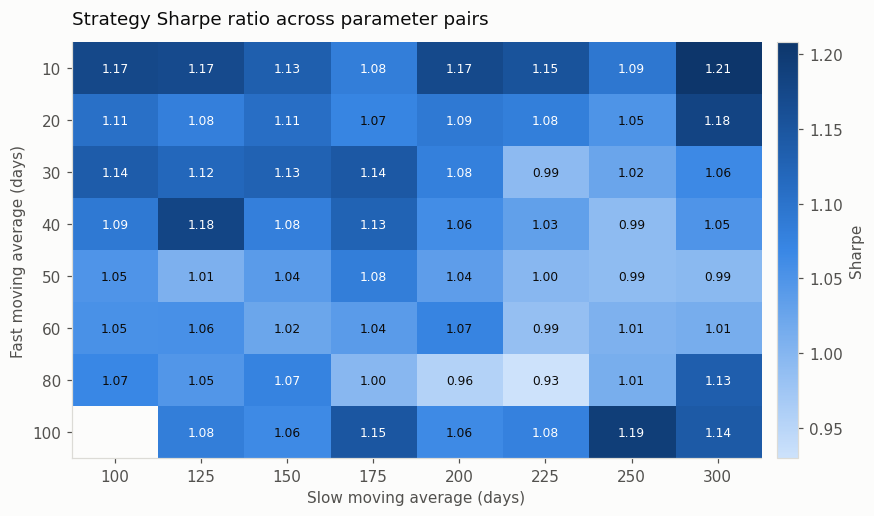

In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
im = ax.imshow(sharpe.values.astype(float), cmap=SEQ, aspect="auto")
ax.set_xticks(range(len(slows)), slows); ax.set_yticks(range(len(fasts)), fasts)
ax.set_xlabel("Slow moving average (days)"); ax.set_ylabel("Fast moving average (days)")
ax.set_title("Strategy Sharpe ratio across parameter pairs", loc="left",
             fontsize=12, color=INK, pad=12)
ax.grid(False)
for i, f in enumerate(fasts):
    for j, s_ in enumerate(slows):
        v = sharpe.loc[f, s_]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="#ffffff" if v > np.nanmedian(sharpe.values.astype(float)) else INK)
cb = fig.colorbar(im, ax=ax, pad=0.02); cb.set_label("Sharpe", color=MUTED)
cb.outline.set_edgecolor(GRID)
plt.tight_layout(); plt.show()

Read the heatmap as a surface, not a table of candidates. A **broad plateau** of
similar values means the effect survives parameter choice. A **single bright cell**
surrounded by poor ones means the 50/200 result was luck.

Whatever the chart shows, that is the finding. Reporting only the best cell is the
thing this section exists to prevent.


## 6. The same rule on the FTSE 100

A result on one asset is not evidence about trend following. The cell below runs the
identical function over the FTSE 100 from 2006 and reports both assets side by side:
the 50/200 headline, and how many of the 63 parameter pairs beat buy and hold on
Sharpe.

This is the part that makes the finding interesting. The rule is the same; only the
market changed.


In [9]:
def run_asset(ticker, start, end, label):
    raw_ = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    p = raw_["Close"]
    if isinstance(p, pd.DataFrame):
        p = p.iloc[:, 0]
    p = p.dropna()

    ppy = periods_per_year(p.index)
    base_sig = build_signals(p)
    base, _  = backtest(base_sig)
    bh = stats(base["BuyHold"],  base["BuyHold_Cum"],  ppy)
    st = stats(base["Strategy"], base["Strategy_Cum"], ppy)
    # recompute numerically: stats() returns formatted strings, not floats
    bh_sharpe = (base["BuyHold"].mean() * ppy
                 / (base["BuyHold"].std() * np.sqrt(ppy)))

    wins = total = 0
    for f in FASTS:
        for s_ in SLOWS:
            if f >= s_:
                continue
            r_, _ = backtest(build_signals(p, f, s_))
            vol = r_["Strategy"].std() * np.sqrt(ppy)
            total += 1
            if vol > 0 and r_["Strategy"].mean() * ppy / vol > bh_sharpe:
                wins += 1

    return {
        "Years":              f"{len(p)/ppy:.1f}",
        "B&H Sharpe":         bh["Sharpe"],
        "Strategy Sharpe":    st["Sharpe"],
        "B&H max drawdown":   bh["Max Drawdown"],
        "Strategy max DD":    st["Max Drawdown"],
        "Time in market":     f"{base_sig['Position'].mean():.0%}",
        "Pairs beating B&H":  f"{wins} of {total}",
    }

comparison = pd.DataFrame({
    "Bitcoin (2014-)":  run_asset("BTC-USD", "2014-09-17", END, "Bitcoin"),
    "FTSE 100 (2006-)": run_asset("^FTSE",   "2006-01-01", END, "FTSE 100"),
})
comparison


,Bitcoin (2014-),FTSE 100 (2006-)
Years,12.0,20.6
B&H Sharpe,0.98,0.27
Strategy Sharpe,1.04,0.20
B&H max drawdown,-83.4%,-47.8%
Strategy max DD,-69.3%,-37.3%
Time in market,58%,65%
Pairs beating B&H,61 of 63,2 of 63


The two columns disagree, and the disagreement is the result.

On the FTSE 100 the filter cut drawdown and lost on Sharpe, and almost no parameter
pair beat buy and hold. On Bitcoin the same rule cut a far deeper drawdown and the
great majority of pairs beat buy and hold on Sharpe.

The readable explanation is trend persistence and volatility. A 200-day average is a
slow filter; it only earns its cost when drawdowns are deep enough and long enough
for being flat to be worth more than the entries it misses. Bitcoin's bear markets
were both. The FTSE's were not.

Two things to hold against the Bitcoin column before treating it as a finding:

- **Sortino goes the other way.** The strategy improves Sharpe but not Sortino,
  because sitting flat 58% of the time removes upside faster than it removes
  downside deviation. Sharpe alone would have hidden that.
- **One asset, one sample.** Bitcoin's history is twelve years and one long secular
  uptrend. That is a small number of independent cycles to conclude anything from.


## 7. Limitations

- **One asset, a short history.** Twelve years of Bitcoin is a handful of cycles, all
  inside one secular uptrend. The FTSE comparison widens the evidence but two markets
  is still two markets.
- **Survivorship in the asset itself.** Bitcoin is being tested because it survived
  and rose. The same rule on an asset that went to zero would read very differently,
  and that sample is not in the data.
- **Costs are a flat 10bps** per position change, with no slippage or market-impact
  model. Crypto spreads and exchange fees have varied enormously across this period,
  and were far worse in 2014 to 2017 than the flat figure assumes.
- **No short leg.** The strategy goes to cash, never short, so it can avoid
  downtrends but not profit from them.
- **No interest on cash.** While flat, the strategy earns nothing here. Crediting a
  cash rate would improve it further, so this omission is conservative.
- **Backtests are not forecasts.** The sweep guards against fitting one pair, not
  against fitting one period. Nothing here is investment advice or a trading system.
